# <span style="color:darkblue"> QTM 151 Final Project: Time Analysis </span>

# <span style="color:darkblue"> I. Team Members </span>

In [2]:
print("Grace Chen, Matthew Dang, Lynne Zheng")

Grace Chen, Matthew Dang, Lynne Zheng


# <span style="color:darkblue"> II. Introduction </span>

In [4]:
#  A markdown text with 1-2 paragraph that summarize the main goals of the project. The first paragraph should briefly describe what Formula 1 is, what
# question you’re interested in, and why it is relevant. The introduction should end
# with a high-level description of the results and the coming structure of the
# project. Try to make the text self-contained, intended for someone who isn’t
# familiar with Formula 1 or the dataset.

<font size = "4">
Formula 1, or also known as F1, is the world's most popular motorsport racing circuit. The best drivers around the world sign with teams to compete, all with their own special cars and pit crews to give them a competitive edge. In order to get a better understanding of race times in F1, we decided to do our project on Time Analysis Tables. There are many variables that correlate to times, such as pit stop durations, time trends over different race events, and how times have improved over time due to technology and the sharpening of driver skill. 

<font size = "4">
Our final project will mainly answer two questions:<br>

- **Question 1**: Have lap times improved significantly over the years?<br>

- **Question 2**: Are pit stop durations correlated with race outcomes?

# <span style="color:darkblue"> III. Data Description </span>

<font size = "5">
Import Libraries

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import os

<font size = "5">
Import Data

<font size = 3>
We selected three tables to perform the analysis, which include races, lap_times, results, and pit_stops.

Some Important rows we will be looking into are:
* races
    1. [name]: We chose the Turkish Grand Prix for this project. Using the name, we were able to extract all instances of the Turkish Grand Prix across different years to analyze times
* lap_times
    1. [miliseconds]: We chose to use miliseconds to put on our y-axis. Using this standardized time, we can use it as a benchmark to see any correlation between overall times and lap times.
    2. [raceId]: Using [raceId], we were able to match lap times to specific races, and then match them to the pit stop times within the lap. 
* pit_stops
    1. [raceId]: Use the identified raceIDs from race file and extrac the data.
    2. [milliseconds]: Identify the duration of the pit_stops in milliseconds for the Turkish Grand Prix
* results
    1. [raceId]: Use the identified raceIDs from the race file and extract the data.
    2. [milliseconds]: We identify the duration for the results in milliseconds for the Turkish Grand Prix.



In [17]:
races = pd.read_csv("data_raw/races.csv")
lap_times = pd.read_csv("data_raw/lap_times.csv")
pit_stops = pd.read_csv("data_raw/pit_stops.csv")
results = pd.read_csv("data_raw/results.csv")
print(results)

       resultId  raceId  driverId  constructorId number  grid position  \
0             1      18         1              1     22     1        1   
1             2      18         2              2      3     5        2   
2             3      18         3              3      7     7        3   
3             4      18         4              4      5    11        4   
4             5      18         5              1     23     3        5   
...         ...     ...       ...            ...    ...   ...      ...   
25835     25841    1096       854            210     47    12       16   
25836     25842    1096       825            210     20    16       17   
25837     25843    1096         1            131     44     5       18   
25838     25844    1096       849              3      6    20       19   
25839     25845    1096         4            214     14    10       \N   

      positionText  positionOrder  points  laps         time milliseconds  \
0                1              1 

# <span style="color:darkblue"> IV. Results </span>

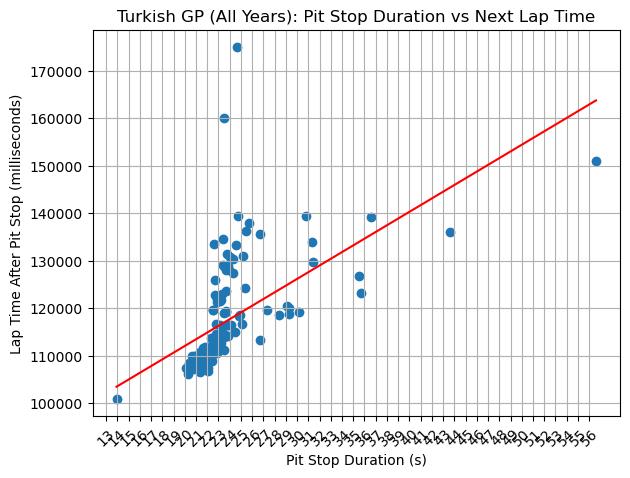

In [10]:
turkishgp = races[races['name'].str.contains('Turkish', case=False)]
turkeyraceids = turkishgp['raceId'].tolist()
turkeypitstops = pit_stops[pit_stops['raceId'].isin(turkeyraceids)]
turkeylaptimes = lap_times[lap_times['raceId'].isin(turkeyraceids)]
turkeypitstops = turkeypitstops.dropna(subset=['duration'])
pit_lap_merge = pd.merge(
    turkeypitstops,
    turkeylaptimes,
    on=['raceId', 'driverId'],
    how='inner'
)
pit_lap_merge = pit_lap_merge[pit_lap_merge['lap_y'] == pit_lap_merge['lap_x'] + 1]
pit_lap_merge = pit_lap_merge.rename(columns={
    'lap_x': 'pit_lap',
    'lap_y': 'lap_after_pit',
    'time_y': 'lap_time',
    'milliseconds_y': 'lap_time_milliseconds'
})
pit_lap_merge['duration'] = pd.to_numeric(pit_lap_merge['duration'], errors='coerce')
pit_lap_merge = pit_lap_merge.dropna(subset=['duration'])

plt.scatter(pit_lap_merge['duration'], pit_lap_merge['lap_time_milliseconds'])
m, b = np.polyfit(pit_lap_merge['duration'], pit_lap_merge['lap_time_milliseconds'], 1)
x = np.linspace(pit_lap_merge['duration'].min(), pit_lap_merge['duration'].max(), 100)
y = m * x + b
plt.plot(x, y, color='red', label=f'Regression Line\ny = {m:.2f}x + {b:.0f}')
plt.xlabel('Pit Stop Duration (s)')
plt.ylabel('Lap Time After Pit Stop (milliseconds)')
plt.title('Turkish GP (All Years): Pit Stop Duration vs Next Lap Time')
plt.tight_layout() 
plt.grid(True)
plt.xticks(
    ticks=np.arange(int(pit_lap_merge['duration'].min()), int(pit_lap_merge['duration'].max()) + 1, 1), 
    rotation=45
)
plt.show()

# <span style="color:darkblue"> V. Discussion </span>

Through our linear regression scatter plot, we can see that pit stop times do in fact have a correlation with overall lap times. The shorter the pit stop, the faster the time, and vice versa. The red line represents the average increase in time for each 1 second extra in pit stop duration, showing that there is a positive correlation (or in this case I guess it would be a bad thing). 

However, our regression does not prove causation. While there is data to suggest pit stop times are correlated with lap times, other variables such as driver skill and any small accidents/bumps could have been the reason for slower times, not just pit stop times.